In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

%load_ext autoreload
%autoreload 2

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Folder now changed for saving 
output_folder = output_folder / "03_trade_offs" # scatter_taxonomy"
output_folder.mkdir(exist_ok=True)


# Trade-offs etc 

In [29]:
df_gnm_g = dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"].groupby(["eta", "gamma"]).mean().reset_index()
cols_of_interest = [col for col in df_gnm_g.columns if col not in ["eta", "gamma"]]

In [30]:
datasets_to_look_at = [
                'hcp_schaefer_100_dataset_gnm', 
                # 'hcp_schaefer_100_dataset',
                # 'kaysons_generated_networks_topology', 
                'suarez_MaMI_dataset', 
                'lexis_data_young', 
                'lexis_data_aging', 
                'lexis_data_developing', 
                
                'kaysons_generated_networks_diffusion', 
                'kaysons_generated_networks_propagation', 
                'kaysons_generated_networks_routing', 
]

Text(0.5, 0, '$f_{{\\rm LR\\,(10\\%)}}$')

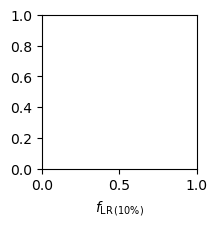

In [31]:
plt.figure(figsize=(2,2))
# plt.xlabel(r"$\eta$")
plt.xlabel(r"$f_{{\rm LR\,(10\%)}}$")

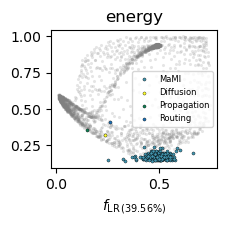

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/3270626794.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=6)


Save path:  /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs


In [32]:

x_name = "proportion_long_range_connections_0.3956"

for idx, col in enumerate(cols_of_interest):
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

    plt.scatter(df_gnm_g[x_name], df_gnm_g[col], 
               color="gray", linewidth=0, s=5, alpha=0.2) 

    if len(col) > 20:
        col_for_title = re.split(r'[,,_]+', col)
        len_col = len(col_for_title)
        col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

    if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
        col = "min_value"
        col_for_title = "Distance Measure"

    for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]

        if col in df_merged.columns:
            plt.scatter(df_merged[x_name], # df_merged["eta"], df_merged['gamma'],
                       df_merged[col],
                    #    c = df_merged[col],
                       edgecolor="black",
                       color=COLOR_SCHEME[dataset],
                       linewidth=0.25, s=5, label=LABEL_MAP[dataset]
            ) #  alpha=0.7)

    plt.xlabel(PROPERTY_NAMES[x_name]) # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.title(col) # , fontsize=6)
    plt.legend(fontsize=6)
    plt.tight_layout()
    plt.savefig(output_folder / f"fig_{idx}_{col}_scatter.png", dpi=200)
    if idx == 0:
        plt.show()
    else: 
        plt.close()

print("Save path: ", output_folder)

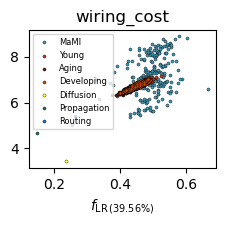

Save path:  /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs


In [33]:

x_name = "proportion_long_range_connections_0.3956"
col = "wiring_cost"
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])


for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged[x_name], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5, label=LABEL_MAP[dataset]
        ) #  alpha=0.7)

plt.xlabel(PROPERTY_NAMES[x_name]) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)
plt.legend(fontsize=6)
plt.tight_layout()
plt.savefig(output_folder / f"fig_{idx}_{col}_scatter_w_o_gnm.png", dpi=200)
plt.show()

print("Save path: ", output_folder)

In [34]:
df_gnm_g

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,-8.0,-0.100000,0.931,0.015520,68.912802,34111.837109,2.237475,35.3,74.740613,8.379198,...,221.65,0.44869,0.485927,0.923368,0.487,0.4983,2.666178,0.133791,0.812038,0.468
1,-8.0,-0.077551,0.934,0.015567,68.775390,34043.817578,2.238646,37.1,69.670481,8.407290,...,221.60,0.45505,0.486249,0.935839,0.491,0.4969,2.440664,0.123242,0.711938,0.440
2,-8.0,-0.055102,0.939,0.015572,68.838924,34075.267188,2.234909,39.2,72.679114,8.320874,...,221.55,0.45774,0.486455,0.940996,0.493,0.4981,3.068431,0.152928,0.871220,0.638
3,-8.0,-0.032653,0.933,0.015549,68.495776,33905.408984,2.235697,37.8,67.709734,8.379292,...,221.35,0.45647,0.486966,0.937376,0.493,0.4985,3.019175,0.153873,0.870720,0.638
4,-8.0,-0.010204,0.936,0.015602,69.017478,34163.651563,2.235172,35.9,69.975212,8.336929,...,222.90,0.45472,0.486586,0.934556,0.487,0.4976,2.993023,0.151654,0.880869,0.610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3.0,0.910204,0.326,0.008264,71.699420,35491.212891,5.133980,128.4,83.668096,6.750237,...,99.00,0.35920,0.362585,0.992445,0.339,0.3015,0.019267,0.000615,0.330887,0.478
2496,3.0,0.932653,0.317,0.008387,73.086583,36177.858594,4.907172,126.9,84.562829,6.856519,...,99.00,0.35498,0.366310,0.977248,0.344,0.3065,0.022783,0.000728,0.341379,0.460
2497,3.0,0.955102,0.338,0.008264,73.510998,36387.944141,5.132020,126.7,84.072289,6.675188,...,99.00,0.35127,0.357857,0.987608,0.333,0.2983,0.021020,0.000681,0.392371,0.452
2498,3.0,0.977551,0.313,0.008357,73.208488,36238.201172,4.634364,123.8,85.426667,6.802856,...,99.00,0.34037,0.369171,0.929514,0.319,0.3097,0.033159,0.001035,0.414867,0.426


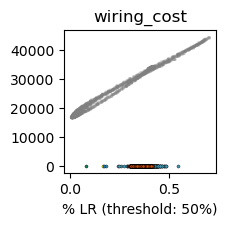

In [35]:

fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

plt.scatter(df_gnm_g["proportion_long_range_connections_0.5"], df_gnm_g[col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at:

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if col in df_merged.columns:
        plt.scatter(df_merged["proportion_long_range_connections_0.5"], # df_merged["eta"], df_merged['gamma'],
                    df_merged[col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    linewidth=0.25, s=5)

plt.xlabel("% LR (threshold: 50%)") # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.title(col) # , fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/427015981.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


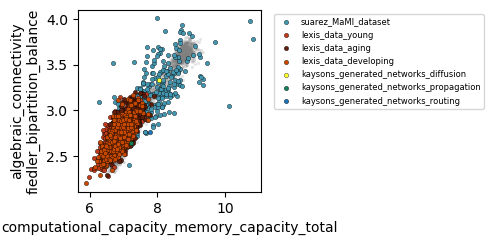

In [36]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at:

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/216149244.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


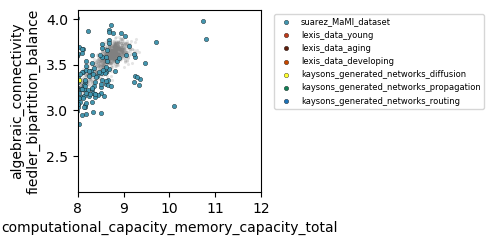

In [37]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at:

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlim(8,12) # Set x-axis limits to 0 and 1
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/2464462355.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


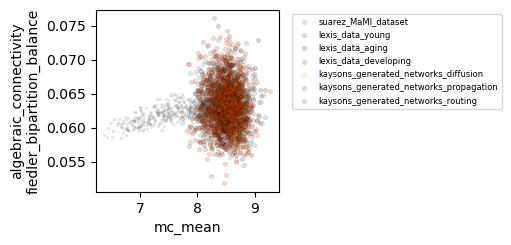

In [38]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "mc_mean" # computational_capacity_memory_capacity_total"
y_col = "mc_nonlinear_original_mc_mean"
# " # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at:

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10, 
                    alpha=0.2
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/561538964.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


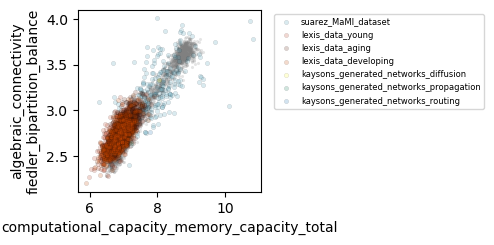

In [39]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    alpha=0.2, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/22135294.py:57: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


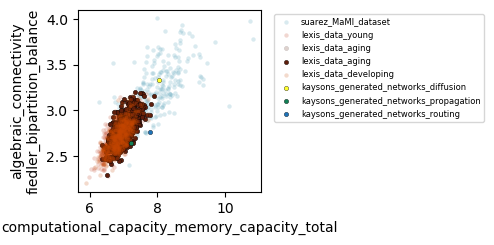

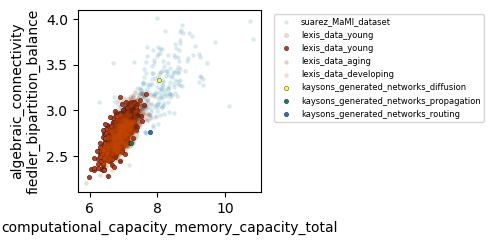

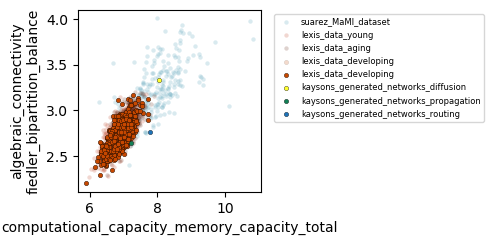

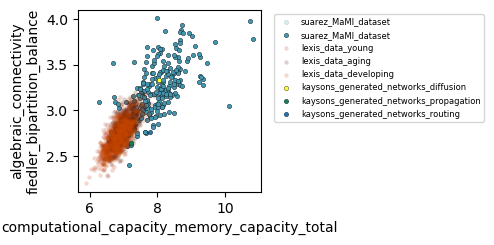

In [40]:


x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
# plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
#             color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset_to_highlight in ["aging", "young", "developing", "MaMI"]: # , "kayson"
    fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    
    
    for dataset in datasets_to_look_at:

        # Skip the gnm dataset, as it will now have two eta and gamma columns. 
        if dataset == "hcp_schaefer_100_dataset_gnm":
            continue

        df_merged = dict_with_all_datasets[dataset]

        if y_col in df_merged.columns:
            plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                        df_merged[y_col],
                    #    c = df_merged[col],
                        edgecolor="black",
                        color=COLOR_SCHEME[dataset],
                        label=dataset,
                        linewidth=0.25 if ("kayson" in dataset) or (dataset_to_highlight in dataset) else 0, 
                        alpha=1 if "kayson" in dataset else 0.2,
                        s=10
                        )
            
        # Plot again over it to highlight the dataset of interest (e.g., "aging" or "kayson")
        if dataset_to_highlight in dataset:
            plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                            df_merged[y_col],
                        #    c = df_merged[col],
                            edgecolor="black",
                            color=COLOR_SCHEME[dataset],
                            label=dataset,
                            linewidth=0.25, #  if ("kayson" in dataset) or (dataset_to_highlight in dataset) else 0, 
                            alpha=1, #  if "kayson" in dataset else 0.2,
                            s=10
                            )
    # plt.xscale("log")
    plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
    # plt.ylabel(col.replace("_", " ").capitalize())
    # if the title is too long (define this), then split it into two lines at the last underscore
    plt.ylabel(col_for_title) # , fontsize=6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

    plt.tight_layout()
    plt.show()


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1503087535.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


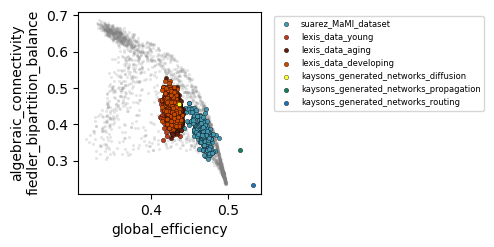

In [41]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "global_efficiency" # computational_capacity_memory_capacity_total"
y_col = "modularity" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/551605530.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


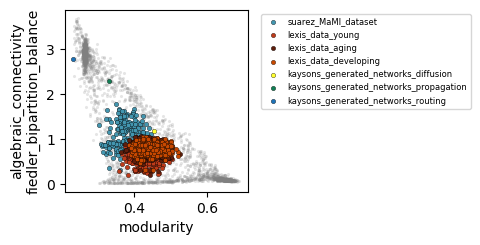

In [42]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "modularity" # computational_capacity_memory_capacity_total"
y_col = "algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1939865138.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # TODO: INCLUDE IN DOCS


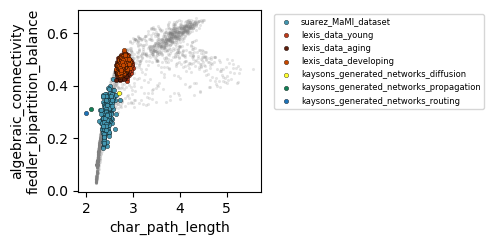

In [43]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "char_path_length" # modularity" # computational_capacity_memory_capacity_total"
y_col = "avg_clustering" # algebraic_connectivity_fiedler_value" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black", 
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout() # TODO: INCLUDE IN DOCS

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1359151764.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


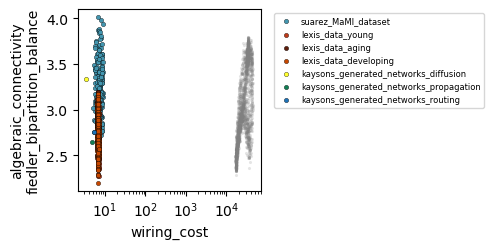

In [44]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"


plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"



for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/2605229334.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


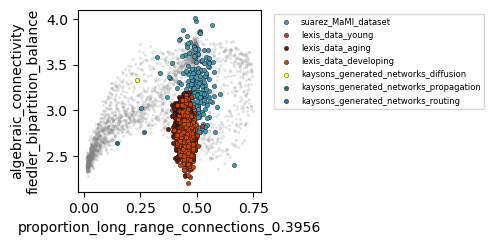

In [45]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "proportion_long_range_connections_0.3956" # wiring_cost"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: #  dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/2899966051.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


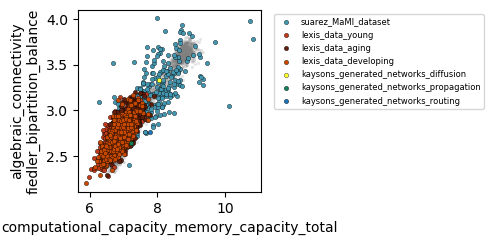

In [46]:
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "computational_capacity_memory_capacity_total"
y_col = "computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1633758110.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


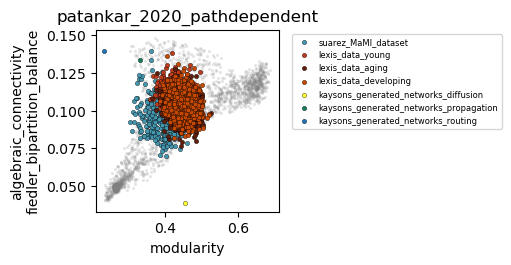

In [47]:
# patankar_2020_pathdependent
 
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "modularity" # computational_capacity_memory_capacity_total"
y_col = "nct_control_std" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
plt.title("patankar_2020_pathdependent")
plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/2670054109.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


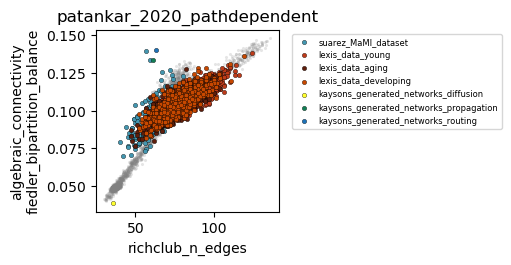

In [48]:
# patankar_2020_pathdependent
 
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

x_col = "richclub_n_edges" # computational_capacity_memory_capacity_total"
y_col = "nct_control_std" # computational_capacity_nonlinear_capacity_total"
plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(x_col) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
plt.title("patankar_2020_pathdependent")
plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/402963634.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


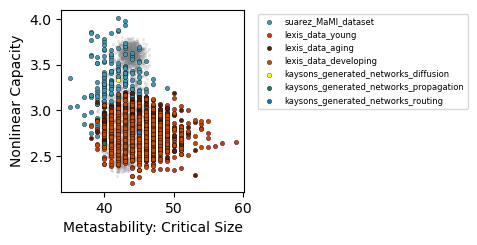

In [49]:
# patankar_2020_pathdependent
 
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

y_col = "computational_capacity_nonlinear_capacity_total" # 
# y_col = "computational_capacity_memory_capacity_total" # computational_capacity_memory_capacity_total"
# x_col = "repertoire_sweep_weighted_by_distances_T_critical" # 
x_col = "repertoire_sweep_weighted_by_distances_size_critical" # "repertoire_sweep_weighted_by_distances_diversity_critical" # "nct_control_std" # computational_capacity_nonlinear_capacity_total"

plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

col_for_title = PROPERTY_NAMES[y_col] if y_col in PROPERTY_NAMES else y_col
if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                #    c = df_merged[col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

# plt.xscale("log")
plt.xlabel(PROPERTY_NAMES[x_col]) # Percentage of\nLR connections (> 50 % length)")
# plt.ylabel(col.replace("_", " ").capitalize())
# if the title is too long (define this), then split it into two lines at the last underscore
plt.ylabel(col_for_title) # , fontsize=6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
# plt.title("patankar_2020_pathdependent")
plt.tight_layout()

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1248260367.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


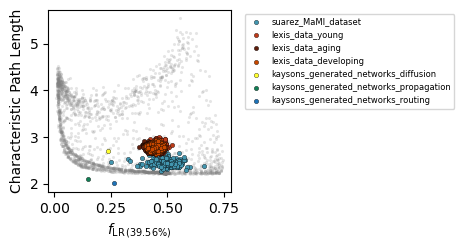

In [50]:
# kaiser_2006_nonoptimal
 
fig = plt.figure(figsize=viz.cm_to_inch((6,6)))    

y_col = "char_path_length"
x_col = "proportion_long_range_connections_0.3956" 

plt.scatter(df_gnm_g[x_col], df_gnm_g[y_col], 
            color="gray", linewidth=0, s=5, alpha=0.2) 

col_for_title = PROPERTY_NAMES[y_col] if y_col in PROPERTY_NAMES else y_col
if len(col) > 20:
    col_for_title = re.split(r'[,,_]+', y_col)
    len_col = len(col_for_title)
    col_for_title = "_".join(col_for_title[:len_col//2]) + "\n" + "_".join(col_for_title[len_col//2:])

if col == "MaxCriteria(DegreeKS, ClusteringKS, EdgeLengthKS, BetweennessKS)": 
    col = "min_value"
    col_for_title = "Distance Measure"

for dataset in datasets_to_look_at: # dict_with_all_datasets.keys():

    # Skip the gnm dataset, as it will now have two eta and gamma columns. 
    if dataset == "hcp_schaefer_100_dataset_gnm":
        continue

    df_merged = dict_with_all_datasets[dataset]

    if y_col in df_merged.columns:
        plt.scatter(df_merged[x_col], # df_merged["eta"], df_merged['gamma'],
                    df_merged[y_col],
                    edgecolor="black",
                    color=COLOR_SCHEME[dataset],
                    label=dataset,
                    linewidth=0.25, 
                    s=10
                    )

plt.xlabel(PROPERTY_NAMES[x_col])
plt.ylabel(col_for_title)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)

plt.tight_layout()

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_24701/1324569100.py:14: SyntaxWarning: invalid escape sequence '\%'
  x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"


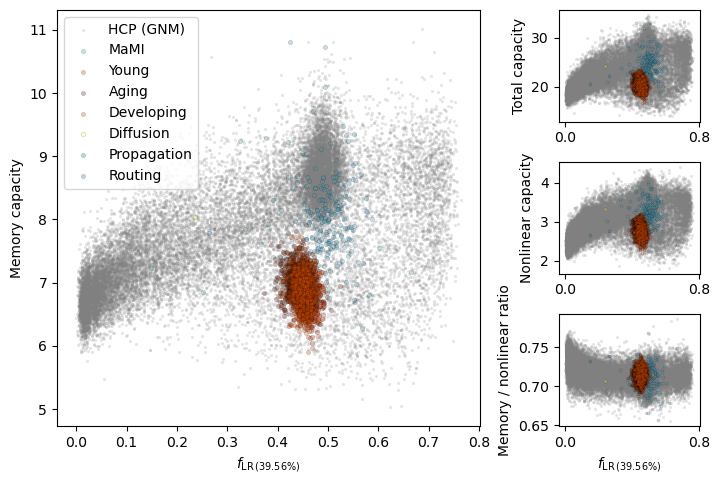

In [51]:
# output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
# output_folder = output_folder / "trade_off_scatters"
# output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        # print(dataset, len(df_merged.columns))
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color="gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 5,
                alpha=0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [52]:
# output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
# output_folder = output_folder / "trade_off_scatters"
# output_folder.mkdir(exist_ok=True)

# x_col = "proportion_long_range_connections_0.3956"

# panels = {
#     "A": ("targeted_attack_robustness_rob_targeted_auc",    "Robn"),
#     "B": ("targeted_attack_robustness_rob_total_capacity",           "Total capacity"),
#     "C": ("targeted_attack_robustness_rob_nonlinear_capacity", "Nonlinear capacity"),
#     # "D": ("targeted_attack_robustness_rob_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
# }

# x_label = f"$f_{{\\rm LR\\,(39.56\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# # ── mosaic layout ─────────────────────────────────────────────────────────────
# fig, axes = plt.subplot_mosaic(
#     """
#     ABC 
#     """,
#     figsize=viz.cm_to_inch((18, 12)),
#     layout="constrained",
#     # share x across the small panels so zoom/pan stays in sync
#     per_subplot_kw={
#         "B": {"sharex": None},   # placeholder; real sharing done below
#     },
# )

# # Share x-axis of B, C, D with each other (not with A — limits differ)
# axes["C"].sharex(axes["B"])
# # axes["D"].sharex(axes["B"])

# # ── shared plotting function ──────────────────────────────────────────────────
# def plot_panel(ax, y_col, y_label, is_main=False):
#     for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
#         df_merged = dict_with_all_datasets[dataset] # for dataset, df_merged in dict_with_all_datasets.items():
#         print(dataset, len(df_merged.columns))
#         if dataset == "hcp_schaefer_100_dataset_gnm":
#             # ax.scatter(
#             #     df_merged[x_col],
#             #     df_merged[y_col],
#             #     color=COLOR_SCHEME[dataset],
#             #     edgecolor="black",
#             #     linewidth=0.25,
#             #     s=10 if is_main else 5,
#             #     alpha=0.02 if "gnm" in dataset else 0.3,
#             #     label=LABEL_MAP[dataset],
#             # )
#             ax.scatter(
#                 df_merged[x_col],
#                 df_merged[y_col],
#                 color="gray",
#                 linewidth=0,
#                 s=5,
#                 alpha=0.2, 
#                 label=LABEL_MAP[dataset]
#             )   
#         #     print("Skipped")
#         #     continue
#         else: 
#             if x_col not in df_merged.columns or y_col not in df_merged.columns:
#                 print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
#                 continue

#             ax.scatter(
#                 df_merged[x_col],
#                 df_merged[y_col],
#                 color=COLOR_SCHEME[dataset],
#                 edgecolor="black",
#                 linewidth=0.25,
#                 s=10 if is_main else 5,
#                 alpha=0.02 if "gnm" in dataset else 0.3,
#                 label=LABEL_MAP[dataset],
#             )

#     ax.set_xlabel(x_label)
#     ax.set_ylabel(y_label)

#     if is_main:
#         ax.legend()

# # ── draw panels ───────────────────────────────────────────────────────────────
# for panel_id, (y_col, y_label) in panels.items():
#     ax = axes[panel_id]
#     is_main = (panel_id == "A")
#     plot_panel(ax, y_col, y_label, is_main=is_main)

#     # ax.text(
#     #     -0.15 if is_main else -0.35, 1.02,
#     #     panel_id,
#     #     transform=ax.transAxes,
#     #     fontsize=8 if is_main else 6,
#     #     fontweight="bold",
#     #     va="bottom",
#     # )

# # ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
# fig.canvas.draw()                          # force matplotlib to compute auto-ticks

# a_ticks = axes["A"].get_xticks()
# # keep only ticks that fall within A's current view limits
# a_xlim  = axes["A"].get_xlim()
# a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

# first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

# for panel_id in ("B", "C", "D"):
#     ax = axes[panel_id]
#     ax.set_xlim(a_xlim)                    # same data range as A
#     ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
#     # hide x-label on B and C to avoid clutter (only D gets the label)
#     if panel_id != "D":
#         ax.set_xlabel("")

# plt.savefig(output_folder / "pareto_lr_connections.pdf", bbox_inches="tight", dpi=300)
# plt.show()

In [53]:
dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"]

,eta,gamma,energy,avg_communicability,avg_edge_distance,wiring_cost,char_path_length,richclub_n_edges,richclub_avg_length,mc_mean,...,persistent_homology_ph_total_persistence,targeted_attack_robustness_rob_targeted_auc,targeted_attack_robustness_rob_random_auc,targeted_attack_robustness_rob_ratio,targeted_attack_robustness_rob_targeted_half,targeted_attack_robustness_rob_random_half,algebraic_connectivity_fiedler_value,algebraic_connectivity_fiedler_value_norm,algebraic_connectivity_laplacian_spectral_gap,algebraic_connectivity_fiedler_bipartition_balance
0,1.204082,0.304082,0.320000,0.011247,76.077667,37658.445312,2.689091,91.0,81.162041,8.142928,...,104.0,0.3978,0.46037,0.864088,0.44,0.462,0.228483,0.008238,0.689275,0.16
1,-4.857143,0.663265,0.880000,0.014904,63.799976,31580.988281,2.251111,47.0,55.601665,8.059048,...,198.0,0.4446,0.48827,0.910562,0.48,0.500,2.884382,0.133069,0.946072,0.78
2,-5.979592,0.124490,0.940000,0.015729,70.102951,34700.960938,2.230505,36.0,71.146706,8.449266,...,228.5,0.4557,0.48724,0.935268,0.49,0.498,2.883610,0.146973,0.906313,0.56
3,0.530612,0.146939,0.670000,0.013722,69.063416,34186.390625,2.315758,60.0,79.657097,8.598514,...,135.5,0.4182,0.48623,0.860087,0.49,0.493,1.511857,0.061605,0.901723,0.26
4,-3.959184,0.932653,0.438384,0.012760,45.163860,22356.111328,2.409091,64.0,32.699265,8.795462,...,137.5,0.4322,0.48371,0.893511,0.48,0.497,1.735451,0.073960,0.859572,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,-3.285714,-0.032653,0.750000,0.014865,41.555737,20570.089844,2.383232,50.0,32.892582,8.875647,...,168.5,0.4663,0.48473,0.961979,0.50,0.498,1.837761,0.091905,0.791142,0.92
24996,-6.428571,0.887755,0.940000,0.015477,69.142136,34225.355469,2.234747,37.0,76.618568,8.554603,...,217.0,0.4510,0.48442,0.931010,0.49,0.500,1.827213,0.090019,0.549150,0.26
24997,-1.265306,0.685714,0.560000,0.012226,37.178089,18403.154297,4.437778,54.0,34.170551,8.429982,...,99.0,0.3705,0.36101,1.026287,0.43,0.297,0.042775,0.002047,0.474272,0.40
24998,-2.163265,0.842857,0.563636,0.011641,35.095871,17372.457031,4.465657,82.0,27.948391,8.254480,...,99.0,0.3579,0.42099,0.850139,0.30,0.435,0.099793,0.004809,0.633401,0.50


In [54]:
from utils import get_colorchannels_from_eta_gamma

combined_colors = get_colorchannels_from_eta_gamma(dict_with_all_datasets["hcp_schaefer_100_dataset_gnm"], "eta", "gamma") 

hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_network

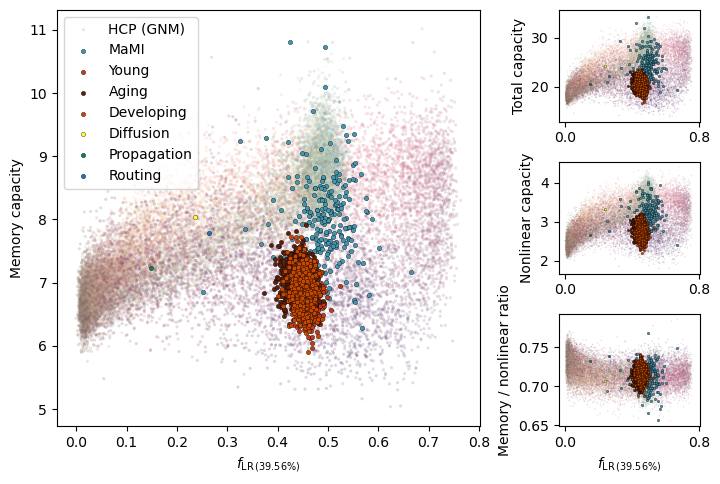

In [55]:
# output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
# output_folder = output_folder / "trade_off_scatters"
# output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset] # for dataset, df_merged in dict_with_all_datasets.items():
        
        print(dataset, len(df_merged.columns), len(df_merged))
        
        # Skip Lexis datasets
        # if "lexi" in dataset:
        #     print("Found lexi dataset, skipping for now.")
        #     continue
        
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            len(df_merged)
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors, # "gray",
                linewidth=0,
                s=5 if is_main else 1,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 3,
                alpha=1, # 0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections_mami_and_hcp_colorful.pdf", bbox_inches="tight", dpi=200)
print(output_folder / "pareto_lr_connections_mami_and_hcp_colorful.pdf")
plt.show()

hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_network

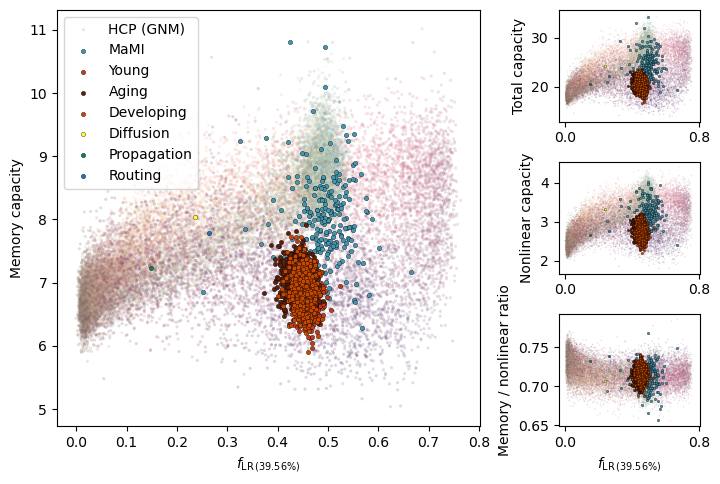

In [56]:
# output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/output") 
# output_folder = output_folder / "trade_off_scatters"
# output_folder.mkdir(exist_ok=True)

x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset] # for dataset, df_merged in dict_with_all_datasets.items():
        
        print(dataset, len(df_merged.columns), len(df_merged))
        
        # Skip Lexis datasets
        # if "lexi" in dataset:
        #     print("Found lexi dataset, skipping for now.")
        #     continue
        
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            len(df_merged)
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors, # "gray",
                linewidth=0,
                s=5 if is_main else 1,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        #     continue
        else: 
            if x_col not in df_merged.columns or y_col not in df_merged.columns:
                print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
                continue

            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=COLOR_SCHEME[dataset],
                edgecolor="black",
                linewidth=0.25,
                s=10 if is_main else 3,
                alpha=1, # 0.02 if "gnm" in dataset else 0.3,
                label=LABEL_MAP[dataset],
            )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

plt.savefig(output_folder / "pareto_lr_connections_mami_and_hcp_colorful.pdf", bbox_inches="tight", dpi=200)
print(output_folder / "pareto_lr_connections_mami_and_hcp_colorful.pdf")
plt.show()

hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_networks_diffusion 174 1
kaysons_generated_networks_propagation 174 1
kaysons_generated_networks_routing 174 1
hcp_schaefer_100_dataset_gnm 175 25000
suarez_MaMI_dataset 174 224
lexis_data_young 170 703
lexis_data_aging 170 687
lexis_data_developing 170 629
kaysons_generated_network

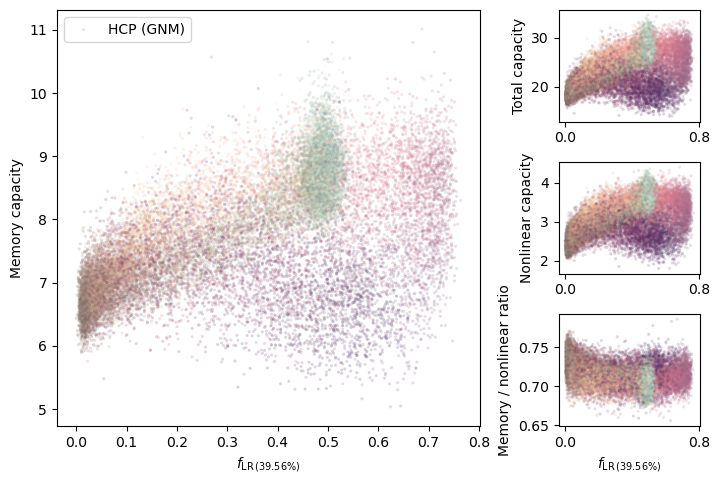

In [57]:
# x_col = "wiring_cost" # 
x_col = "proportion_long_range_connections_0.3956"

panels = {
    "A": ("computational_capacity_memory_capacity_total",    "Memory capacity"),
    "B": ("computational_capacity_total_capacity",           "Total capacity"),
    "C": ("computational_capacity_nonlinear_capacity_total", "Nonlinear capacity"),
    "D": ("computational_capacity_memory_nonlinear_ratio",   "Memory / nonlinear ratio"),
}

x_label = f"$f_{{\\rm LR\\,(39.56\\%)}}$" # "Proportion long-range\nconnections (≥ 0.40)"

# ── mosaic layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplot_mosaic(
    """
    AAAB
    AAAC
    AAAD
    """,
    figsize=viz.cm_to_inch((18, 12)),
    layout="constrained",
    # share x across the small panels so zoom/pan stays in sync
    per_subplot_kw={
        "B": {"sharex": None},   # placeholder; real sharing done below
    },
)

# Share x-axis of B, C, D with each other (not with A — limits differ)
axes["C"].sharex(axes["B"])
axes["D"].sharex(axes["B"])

# ── shared plotting function ──────────────────────────────────────────────────
def plot_panel(ax, y_col, y_label, is_main=False):
    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset] 
        print(dataset, len(df_merged.columns), len(df_merged))
        
        # Skip Lexis datasets
        # if "lexi" in dataset:
        #     print("Found lexi dataset, skipping for now.")
        #     continue
        
        if dataset == "hcp_schaefer_100_dataset_gnm":
            # pass
            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )
            len(df_merged)
            ax.scatter(
                df_merged[x_col],
                df_merged[y_col],
                color=combined_colors, # "gray",
                linewidth=0,
                s=5,
                alpha=0.2, 
                label=LABEL_MAP[dataset]
            )   
        #     print("Skipped")
        # #     continue
        else: 
            pass
            # if x_col not in df_merged.columns or y_col not in df_merged.columns:
            #     print(f"Skipping {dataset} for panel {y_label} because required columns are missing.")
            #     continue

            # ax.scatter(
            #     df_merged[x_col],
            #     df_merged[y_col],
            #     color=COLOR_SCHEME[dataset],
            #     edgecolor="black",
            #     linewidth=0.25,
            #     s=10 if is_main else 5,
            #     alpha=1, # 0.02 if "gnm" in dataset else 0.3,
            #     label=LABEL_MAP[dataset],
            # )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if is_main:
        ax.legend()

# ── draw panels ───────────────────────────────────────────────────────────────
for panel_id, (y_col, y_label) in panels.items():
    ax = axes[panel_id]
    is_main = (panel_id == "A")
    plot_panel(ax, y_col, y_label, is_main=is_main)

    # ax.text(
    #     -0.15 if is_main else -0.35, 1.02,
    #     panel_id,
    #     transform=ax.transAxes,
    #     fontsize=8 if is_main else 6,
    #     fontweight="bold",
    #     va="bottom",
    # )

# ── align small-panel x-ticks to A's outermost ticks ─────────────────────────
fig.canvas.draw()                          # force matplotlib to compute auto-ticks

a_ticks = axes["A"].get_xticks()
# keep only ticks that fall within A's current view limits
a_xlim  = axes["A"].get_xlim()
a_ticks_visible = [t for t in a_ticks if a_xlim[0] <= t <= a_xlim[1]]

first_tick, last_tick = a_ticks_visible[0], a_ticks_visible[-1]

for panel_id in ("B", "C", "D"):
    ax = axes[panel_id]
    ax.set_xlim(a_xlim)                    # same data range as A
    ax.set_xticks([first_tick, last_tick])  # only the two boundary ticks
    # hide x-label on B and C to avoid clutter (only D gets the label)
    if panel_id != "D":
        ax.set_xlabel("")

# plt.savefig(output_folder / "pareto_lr_connections_mami_and_hcp.pdf", bbox_inches="tight", dpi=200)
# plt.show()

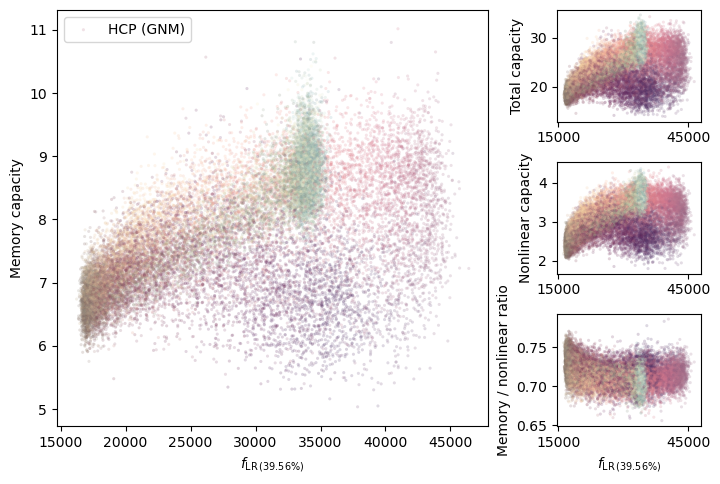

# Further trade-off experiments

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_established_w_o_lexi.pdf


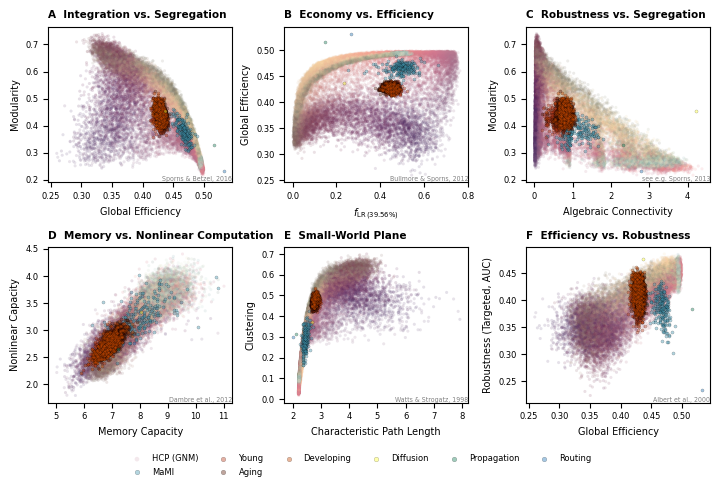

In [58]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────

trade_off_panels = {
    "A": {
        "x": "global_efficiency",
        "y": "modularity",
        "title": "Integration vs. Segregation",
        "ref": "Sporns & Betzel, 2016",
    },
    "B": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "global_efficiency",
        "title": "Economy vs. Efficiency",
        "ref": "Bullmore & Sporns, 2012",
    },
    "C": {
        "x": "algebraic_connectivity_nx",
        "y": "modularity",
        "title": "Robustness vs. Segregation",
        "ref": "see e.g. Sporns, 2013",
    },
    "D": {
        "x": "computational_capacity_memory_capacity_total",
        "y": "computational_capacity_nonlinear_capacity_total",
        "title": "Memory vs. Nonlinear Computation",
        "ref": "Dambre et al., 2012",
    },
    "E": {
        "x": "char_path_length",
        "y": "avg_clustering",
        "title": "Small-World Plane",
        "ref": "Watts & Strogatz, 1998",
    },
    "F": {
        "x": "global_efficiency",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Efficiency vs. Robustness",
        "ref": "Albert et al., 2000",
    },
}

INCLUDE_LEXIS = True # False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12)), layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=7)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=7)
    ax.tick_params(labelsize=6)

    # Panel letter + title
    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7.5, fontweight="bold", loc="left")

    # Reference annotation (bottom-right, small)
    ax.annotate(
        cfg["ref"],
        xy=(1, 0), xycoords="axes fraction",
        fontsize=4.5, color="gray",
        ha="right", va="bottom",
    )

# Single shared legend from panel A
handles, labels = axes_grid["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=6,
    markerscale=1.5,
    frameon=False,
)

plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_established_w_o_lexi.pdf


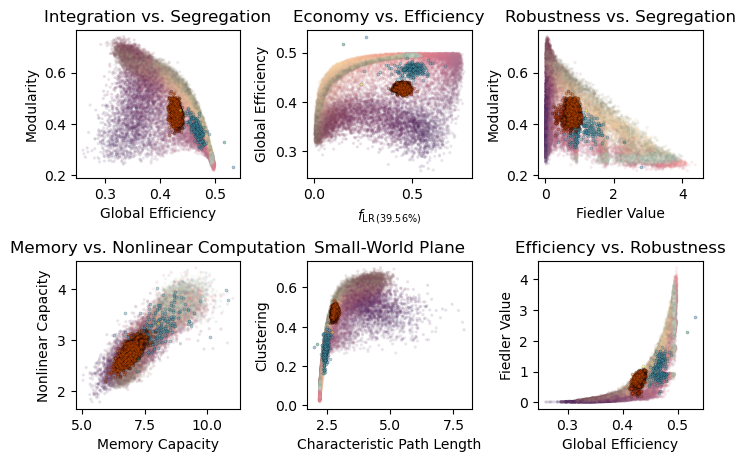

In [59]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
from config import PROPERTY_NAMES


trade_off_panels = {
    "A": {
        "x": "global_efficiency",
        "y": "modularity",
        "title": "Integration vs. Segregation",
        "ref": "Sporns & Betzel, 2016",
    },
    "B": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "global_efficiency",
        "title": "Economy vs. Efficiency",
        "ref": "Bullmore & Sporns, 2012",
    },
    "C": {
        "x": "algebraic_connectivity_fiedler_value", # "algebraic_connectivity_nx",
        "y": "modularity",
        "title": "Robustness vs. Segregation",
        "ref": "see e.g. Sporns, 2013",
    },
    "D": {
        "x": "computational_capacity_memory_capacity_total",
        "y": "computational_capacity_nonlinear_capacity_total",
        "title": "Memory vs. Nonlinear Computation",
        "ref": "Dambre et al., 2012",
    },
    "E": {
        "x": "char_path_length",
        "y": "avg_clustering",
        "title": "Small-World Plane",
        "ref": "Watts & Strogatz, 1998",
    },
    "F": {
        "x": "global_efficiency",
        "y": "algebraic_connectivity_fiedler_value", # "targeted_attack_robustness_rob_targeted_auc",
        "title": "Efficiency vs. Robustness",
        "ref": "Albert et al., 2000",
    },
}

INCLUDE_LEXIS = True # False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"])) # , fontsize=7)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"])) # , fontsize=7)
    ax.tick_params() # labelsize=6)

    # Panel letter + title
    # ax.set_title(f"{panel_id}  {cfg['title']}", # fontsize=7.5, fontweight="bold", 
    #             #  loc="left"
    #              )
    ax.set_title(f"{cfg['title']}", # fontsize=7.5, fontweight="bold", 
                #  loc="left"
                )

    # Reference annotation (bottom-right, small)
    # ax.annotate(
    #     cfg["ref"],
    #     xy=(1, 0), xycoords="axes fraction",
    #     # fontsize=4.5, 
    #     color="gray",
    #     ha="right", va="bottom",
    # )

# # Single shared legend from panel A
# handles, labels = axes_grid["A"].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     # loc="outside lower", #  center",
#     ncol=min(len(labels), 3),
#     # fontsize=6,
#     # markerscale=1.5,
#     # frameon=False,
#     bbox_to_anchor=(0.5, 0), 
#     loc='upper center',
# )

plt.tight_layout()

plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

In [60]:

%load_ext autoreload
%autoreload 2

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs
from config import CATEGORY_ORDER, CATEGORY_COLOURS # Integration etc.
import re
from config import PROPERTY_NAMES, remaining_categories, REPRESENTATIVES_FOR_GOALS, selected_properties


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# # ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
# from config import PROPERTY_NAMES

# trade_off_panels = {
#     "A": {
#         "x": "global_efficiency",
#         "y": "modularity",
#         "title": "Integration vs. Segregation",
#         "ref": "Sporns & Betzel, 2016",
#     },
#     "B": {
#         "x": "proportion_long_range_connections_0.3956",
#         "y": "global_efficiency",
#         "title": "Economy vs. Efficiency",
#         "ref": "Bullmore & Sporns, 2012",
#     },
#     "C": {
#         "x": "algebraic_connectivity_nx",
#         "y": "modularity",
#         "title": "Robustness vs. Segregation",
#         "ref": "see e.g. Sporns, 2013",
#     },
#     "D": {
#         "x": "computational_capacity_memory_capacity_total",
#         "y": "computational_capacity_nonlinear_capacity_total",
#         "title": "Memory vs. Nonlinear Computation",
#         "ref": "Dambre et al., 2012",
#     },
#     "E": {
#         "x": "char_path_length",
#         "y": "avg_clustering",
#         "title": "Small-World Plane",
#         "ref": "Watts & Strogatz, 1998",
#     },
#     "F": {
#         "x": "global_efficiency",
#         "y": "targeted_attack_robustness_rob_targeted_auc",
#         "title": "Efficiency vs. Robustness",
#         "ref": "Albert et al., 2000",
#     },
# }

# INCLUDE_LEXIS = True # False # True

# fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
# axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

# for panel_id, cfg in trade_off_panels.items():
#     ax = axes_grid[panel_id]

#     for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
#         df_merged = dict_with_all_datasets[dataset]
        
#         if (not INCLUDE_LEXIS) and ("lexi" in dataset):
#             print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
#             continue
        
#         x_col = cfg["x"]
#         y_col = cfg["y"]

#         if x_col not in df_merged.columns or y_col not in df_merged.columns:
#             continue

#         is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

#         ax.scatter(
#             df_merged[x_col],
#             df_merged[y_col],
#             color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
#             edgecolor="black" if not is_gnm else "none",
#             linewidth=0.25 if not is_gnm else 0,
#             s=5,
#             alpha=0.15 if is_gnm else 0.4,
#             label=LABEL_MAP[dataset] if panel_id == "A" else None,
#             zorder=1 if is_gnm else 2,
#             rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
#         )

#     # Axis labels from PROPERTY_NAMES (fall back to raw name)
#     ax.set_xlabel(PROPERTY_NAMES[cfg["x"]]) # .replace(" ", "\n")) # .get(cfg["x"], cfg["x"])) # , fontsize=7)
#     ax.set_ylabel(PROPERTY_NAMES[cfg["y"]]) # .replace(" ", "\n")) # .get(cfg["y"], cfg["y"])) # , fontsize=7)
#     ax.tick_params() # labelsize=6)

#     # Panel letter + title
#     # ax.set_title(f"{panel_id}  {cfg['title']}", # fontsize=7.5, fontweight="bold", 
#     #             #  loc="left"
#     #              )
#     ax.set_title(f"{cfg['title']}", # fontsize=7.5, fontweight="bold", 
#                 #  loc="left"
#                 )

#     # Reference annotation (bottom-right, small)
#     # ax.annotate(
#     #     cfg["ref"],
#     #     xy=(1, 0), xycoords="axes fraction",
#     #     # fontsize=4.5, 
#     #     color="gray",
#     #     ha="right", va="bottom",
#     # )

# # # Single shared legend from panel A
# # handles, labels = axes_grid["A"].get_legend_handles_labels()
# # fig.legend(
# #     handles, labels,
# #     # loc="outside lower", #  center",
# #     ncol=min(len(labels), 3),
# #     # fontsize=6,
# #     # markerscale=1.5,
# #     # frameon=False,
# #     bbox_to_anchor=(0.5, 0), 
# #     loc='upper center',
# # )

# plt.tight_layout()

# plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
# print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
# plt.show()

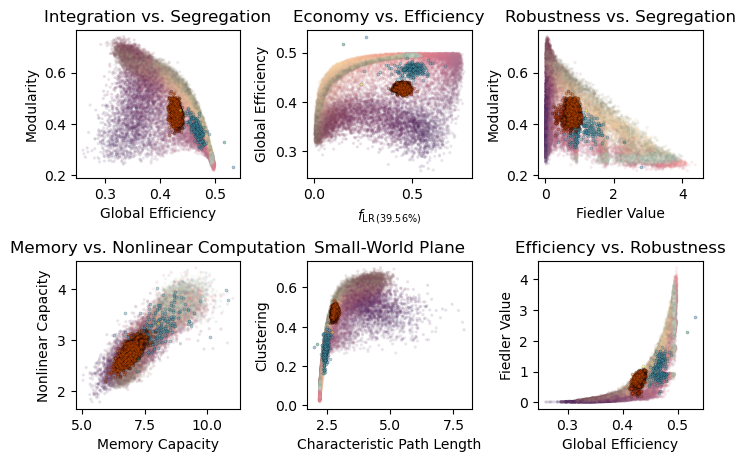

In [62]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
from config import PROPERTY_NAMES

trade_off_panels = {
    "A": {
        "x": "global_efficiency",
        "y": "modularity",
        "title": "Integration vs. Segregation",
        "ref": "Sporns & Betzel, 2016",
    },
    "B": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "global_efficiency",
        "title": "Economy vs. Efficiency",
        "ref": "Bullmore & Sporns, 2012",
    },
    "C": {
        "x": "algebraic_connectivity_fiedler_value", # "algebraic_connectivity_nx",
        "y": "modularity",
        "title": "Robustness vs. Segregation",
        "ref": "see e.g. Sporns, 2013",
    },
    "D": {
        "x": "computational_capacity_memory_capacity_total",
        "y": "computational_capacity_nonlinear_capacity_total",
        "title": "Memory vs. Nonlinear Computation",
        "ref": "Dambre et al., 2012",
    },
    "E": {
        "x": "char_path_length",
        "y": "avg_clustering",
        "title": "Small-World Plane",
        "ref": "Watts & Strogatz, 1998",
    },
    "F": {
        "x": "global_efficiency",
        "y":  "algebraic_connectivity_fiedler_value", # "targeted_attack_robustness_rob_targeted_auc",
        "title": "Efficiency vs. Robustness",
        "ref": "Albert et al., 2000",
    },
}

INCLUDE_LEXIS = True # False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES[cfg["x"]]) # .replace(" ", "\n")) # .get(cfg["x"], cfg["x"])) # , fontsize=7)
    ax.set_ylabel(PROPERTY_NAMES[cfg["y"]]) # .replace(" ", "\n")) # .get(cfg["y"], cfg["y"])) # , fontsize=7)
    ax.tick_params() # labelsize=6)

    # Panel letter + title
    # ax.set_title(f"{panel_id}  {cfg['title']}", # fontsize=7.5, fontweight="bold", 
    #             #  loc="left"
    #              )
    ax.set_title(f"{cfg['title']}", # fontsize=7.5, fontweight="bold", 
                #  loc="left"
                )

    # Reference annotation (bottom-right, small)
    # ax.annotate(
    #     cfg["ref"],
    #     xy=(1, 0), xycoords="axes fraction",
    #     # fontsize=4.5, 
    #     color="gray",
    #     ha="right", va="bottom",
    # )

# # Single shared legend from panel A
# handles, labels = axes_grid["A"].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     # loc="outside lower", #  center",
#     ncol=min(len(labels), 3),
#     # fontsize=6,
#     # markerscale=1.5,
#     # frameon=False,
#     bbox_to_anchor=(0.5, 0), 
#     loc='upper center',
# )

plt.tight_layout()

# plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
# print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_established_w_o_lexi.pdf


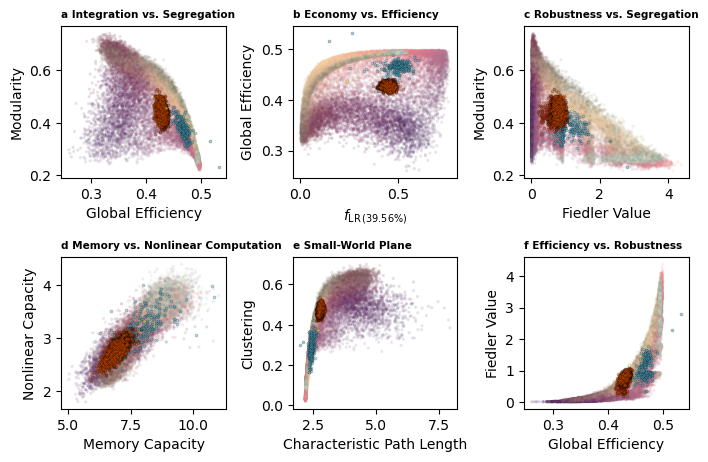

In [63]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
from config import PROPERTY_NAMES

trade_off_panels = {
    "a": {
        "x": "global_efficiency",
        "y": "modularity",
        "title": "Integration vs. Segregation",
        "ref": "Sporns & Betzel, 2016",
    },
    "b": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "global_efficiency",
        "title": "Economy vs. Efficiency",
        "ref": "Bullmore & Sporns, 2012",
    },
    "c": {
        "x": "algebraic_connectivity_fiedler_value", # "algebraic_connectivity_nx",
        "y": "modularity",
        "title": "Robustness vs. Segregation",
        "ref": "see e.g. Sporns, 2013",
    },
    "d": {
        "x": "computational_capacity_memory_capacity_total",
        "y": "computational_capacity_nonlinear_capacity_total",
        "title": "Memory vs. Nonlinear Computation",
        "ref": "Dambre et al., 2012",
    },
    "e": {
        "x": "char_path_length",
        "y": "avg_clustering",
        "title": "Small-World Plane",
        "ref": "Watts & Strogatz, 1998",
    },
    "f": {
        "x": "global_efficiency",
        "y":  "algebraic_connectivity_fiedler_value", # "targeted_attack_robustness_rob_targeted_auc",
        "title": "Efficiency vs. Robustness",
        "ref": "Albert et al., 2000",
    },
}

INCLUDE_LEXIS = True # False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES[cfg["x"]]) 
    ax.set_ylabel(PROPERTY_NAMES[cfg["y"]]) 
    ax.tick_params()

    ax.set_title(f"{panel_id} {cfg['title']}", fontsize=7.5, 
                 fontweight="bold", loc="left")

    # Reference annotation (bottom-right, small)
    # ax.annotate(
    #     cfg["ref"],
    #     xy=(1, 0), xycoords="axes fraction",
    #     # fontsize=4.5, 
    #     color="gray",
    #     ha="right", va="bottom",
    # )

# # Single shared legend from panel A
# handles, labels = axes_grid["A"].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     # loc="outside lower", #  center",
#     ncol=min(len(labels), 3),
#     # fontsize=6,
#     # markerscale=1.5,
#     # frameon=False,
#     bbox_to_anchor=(0.5, 0), 
#     loc='upper center',
# )

plt.tight_layout()

plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
plt.show()

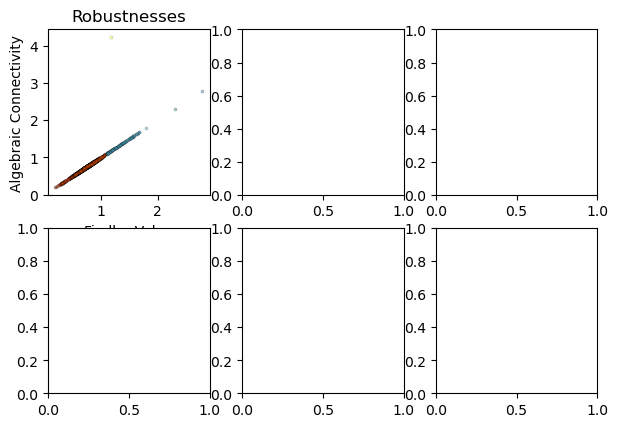

In [64]:
# ── Trade-off grid: 2×3 established pairs ─────────────────────────────────────
from config import PROPERTY_NAMES

trade_off_panels = {
    "A": {
        "x": "algebraic_connectivity_fiedler_value", 
        "y": "algebraic_connectivity_nx", 
        "title": "Robustnesses",
        "ref": "", # Sporns & Betzel, 2016",
    },
}

INCLUDE_LEXIS = True # False # True

fig, axes_flat = plt.subplots(2, 3, figsize=viz.cm_to_inch((18, 12))) # , layout="constrained")
axes_grid = {k: ax for k, ax in zip(trade_off_panels.keys(), axes_flat.ravel())}

for panel_id, cfg in trade_off_panels.items():
    ax = axes_grid[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col = cfg["x"]
        y_col = cfg["y"]

        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"
        if is_gnm: 
            continue

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray"
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,  # rasterize the 90k cloud for fast PDF
        )

    # Axis labels from PROPERTY_NAMES (fall back to raw name)
    ax.set_xlabel(PROPERTY_NAMES[cfg["x"]]) # .replace(" ", "\n")) # .get(cfg["x"], cfg["x"])) # , fontsize=7)
    ax.set_ylabel(PROPERTY_NAMES[cfg["y"]]) # .replace(" ", "\n")) # .get(cfg["y"], cfg["y"])) # , fontsize=7)
    ax.tick_params() # labelsize=6)

    # Panel letter + title
    # ax.set_title(f"{panel_id}  {cfg['title']}", # fontsize=7.5, fontweight="bold", 
    #             #  loc="left"
    #              )
    ax.set_title(f"{cfg['title']}", # fontsize=7.5, fontweight="bold", 
                #  loc="left"
                )
    break


# plt.tight_layout()

# plt.savefig(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf", bbox_inches="tight", dpi=300)
# print(output_folder / f"trade_off_grid_established{'_w_o_lexi' if INCLUDE_LEXIS else ''}.pdf")
# plt.show()

NameError: name 'combined_colors' is not defined

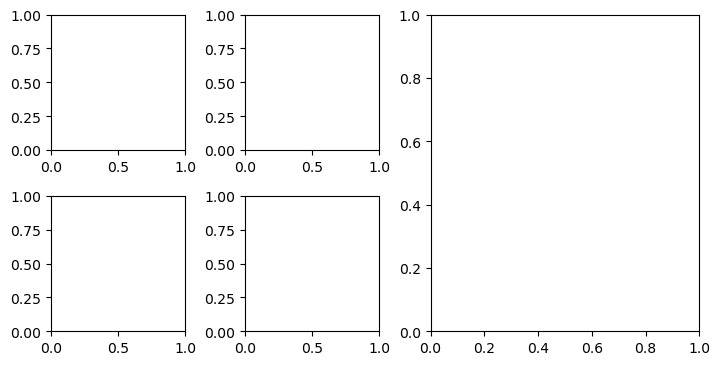

In [26]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        # "x": "ollivier_ricci_curvature_orc_mean",
        # "y": "computational_capacity_memory_nonlinear_ratio",
        "x": "proportion_long_range_connections_0.3956", 
        "y": "char_path_length", 
        "title": "LR to char_path_length",
        "note": "kaiser_2006_nonoptimal",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf", bbox_inches="tight", dpi=200)
print(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_novel_w_o_lexi_with_gnms_new_style.pdf


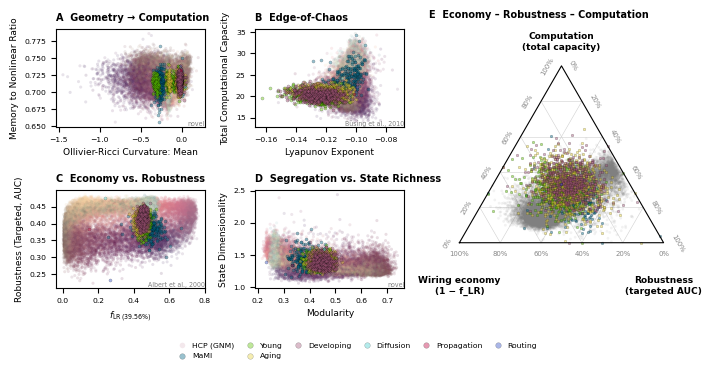

In [39]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "ollivier_ricci_curvature_orc_mean",
        "y": "computational_capacity_memory_nonlinear_ratio",
        "title": "Geometry → Computation",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms_new_style.pdf", bbox_inches="tight", dpi=200)
print(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms_new_style.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_novel_2_w_o_lexi_with_gnms.pdf


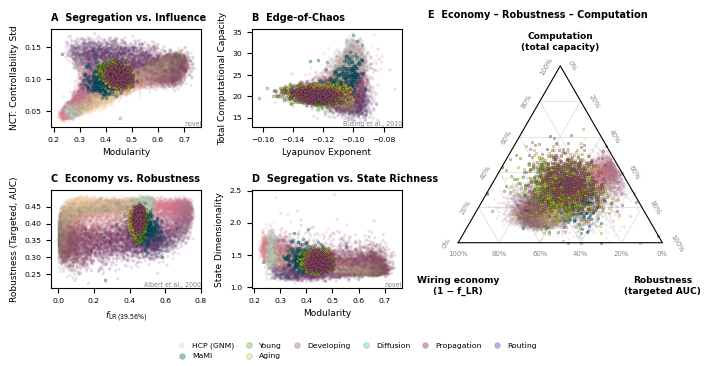

In [40]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "modularity", # "ollivier_ricci_curvature_orc_mean",
        "y": "nct_control_std", # "computational_capacity_memory_nonlinear_ratio",
        "title": "Segregation vs. Influence",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel_2{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf", bbox_inches="tight", dpi=200)
print(output_folder / f"trade_off_grid_novel_2{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_novel_2_efficiencies_w_o_lexi_with_gnms.pdf


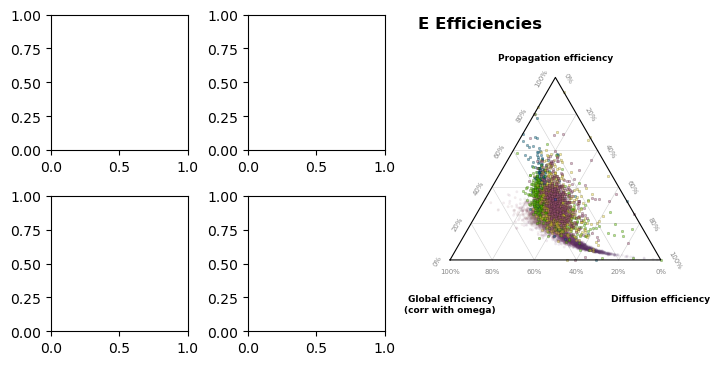

In [41]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "modularity", # "ollivier_ricci_curvature_orc_mean",
        "y": "nct_control_std", # "computational_capacity_memory_nonlinear_ratio",
        "title": "Segregation vs. Influence",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":  "global_efficiency", # corr too highly with omega
    "robustness": "diffusion_efficiency",
    "computation": "propagation_efficiency",

    # "economy":     "proportion_long_range_connections_0.3956",
    # "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    # "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Global efficiency\n(corr with omega)",
    "robustness":  "Diffusion efficiency",
    "computation": "Propagation efficiency",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

# for panel_id, cfg in scatter_panels.items():
#     ax = axes[panel_id]

#     for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
#         df_merged = dict_with_all_datasets[dataset]
        
#         if (not INCLUDE_LEXIS) and ("lexi" in dataset):
#             print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
#             continue
        
#         x_col, y_col = cfg["x"], cfg["y"]
#         if x_col not in df_merged.columns or y_col not in df_merged.columns:
#             continue

#         is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

#         ax.scatter(
#             df_merged[x_col],
#             df_merged[y_col],
#             color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
#             edgecolor="black" if not is_gnm else "none",
#             linewidth=0.25 if not is_gnm else 0,
#             s=5,
#             alpha=0.15 if is_gnm else 0.4,
#             label=LABEL_MAP[dataset] if panel_id == "A" else None,
#             zorder=1 if is_gnm else 2,
#             rasterized=is_gnm,
#         )

#     ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
#     ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
#     ax.tick_params(labelsize=5.5)

#     ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
#     ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
#                 fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E Efficiencies", # , fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    v_economy     = raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums
    # stack = stack + 1e-12

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        # color="gray" if is_gnm else COLOR_SCHEME[dataset],
        color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

# handles, labels = axes["A"].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     loc="outside lower center",
#     ncol=min(len(labels), 6),
#     fontsize=5.5,
#     markerscale=1.8,
#     frameon=False,
#     handletextpad=0.3,
#     columnspacing=1.0,
# )

# # ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel_2_efficiencies{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf", bbox_inches="tight", dpi=200)
print(output_folder / f"trade_off_grid_novel_2_efficiencies{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf")
# plt.show()

In [ ]:


# # ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "propagation_efficiency", # "ollivier_ricci_curvature_orc_mean",
        "y": "mc_mean", # computational_capacity_memory_capacity_total", # "computational_capacity_memory_nonlinear_ratio",
        "title": "Kayson - mc_mean",
        "note": "Kayson - mc_mean",
    },
    "B": {
        "x": "propagation_efficiency",
        "y": "computational_capacity_nonlinear_capacity_total", # computational_capacity_total_capacity",
        "title": "Kayson - nonlinear capacity",
        "note": "Kayson - nonlinear capacity",
    },
    "C": {
        "x": "propagation_efficiency",
        "y": "mc_nonlinear_original_mc_mean",
        "title": "Kayson - mc_nonlinear",
        "note": "Kayson - mc_nonlinear",
    },
    "D": {
        "x": "propagation_efficiency",
        "y": "computational_capacity_memory_capacity_total",
        "title": "Kayson - memory capacity",
        "note": "Kayson - memory capacity",
    },
    
    "E": {
        "x": "propagation_efficiency",
        "y": "computational_capacity_memory_capacity_total",
        "title": "Kayson - memory capacity",
        "note": "Kayson - memory capacity",
    },
}



In [43]:
for a,val in axes.items(): 
    print(a,val)
    val.plot(df_merged[x_col])

A Axes(0.0633437,0.59047;0.193301x0.382248)
B Axes(0.341478,0.59047;0.193301x0.382248)
E Axes(0.582188,0.149216;0.386601x0.752995)
C Axes(0.0633437,0.0787096;0.193301x0.382248)
D Axes(0.341478,0.0787096;0.193301x0.382248)


hcp_schaefer_100_dataset_gnm True
suarez_MaMI_dataset False
lexis_data_young False
lexis_data_aging False
lexis_data_developing False
kaysons_generated_networks_diffusion False
kaysons_generated_networks_propagation False
kaysons_generated_networks_routing False
hcp_schaefer_100_dataset_gnm True
suarez_MaMI_dataset False
lexis_data_young False
lexis_data_aging False
lexis_data_developing False
kaysons_generated_networks_diffusion False
kaysons_generated_networks_propagation False
kaysons_generated_networks_routing False
hcp_schaefer_100_dataset_gnm True
suarez_MaMI_dataset False
lexis_data_young False
lexis_data_aging False
lexis_data_developing False
kaysons_generated_networks_diffusion False
kaysons_generated_networks_propagation False
kaysons_generated_networks_routing False
hcp_schaefer_100_dataset_gnm True
suarez_MaMI_dataset False
lexis_data_young False
lexis_data_aging False
lexis_data_developing False
kaysons_generated_networks_diffusion False
kaysons_generated_networks_propaga

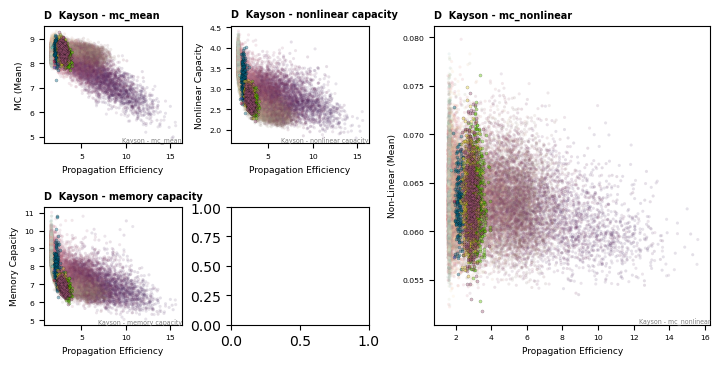

In [45]:
fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

for (label_ax, ax), (label_cfg, cfg) in zip(axes.items(), scatter_panels.items()): 
    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset].copy()
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        if cfg["x"] == "propagation_efficiency": 
            df_merged[x_col] = 1 / df_merged[x_col]
            print(dataset, is_gnm)
            
        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_novel_2_efficiencies_w_o_lexi_with_gnms.pdf


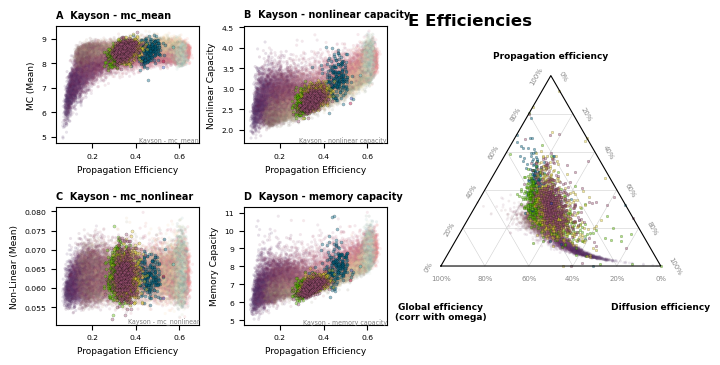

In [140]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Assumes these are already defined in your notebook: ──────────────────────
# dict_with_all_datasets, COLOR_SCHEME, LABEL_MAP, PROPERTY_NAMES, viz
# If running standalone, import/define them above this point.

# ── Output ────────────────────────────────────────────────────────────────────
# output_folder = Path("...your path.../output/trade_off_scatters")
# output_folder.mkdir(exist_ok=True)

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "propagation_efficiency", # "ollivier_ricci_curvature_orc_mean",
        "y": "mc_mean", # computational_capacity_memory_capacity_total", # "computational_capacity_memory_nonlinear_ratio",
        "title": "Kayson - mc_mean",
        "note": "Kayson - mc_mean",
    },
    "B": {
        "x": "propagation_efficiency",
        "y": "computational_capacity_nonlinear_capacity_total", # computational_capacity_total_capacity",
        "title": "Kayson - nonlinear capacity",
        "note": "Kayson - nonlinear capacity",
    },
    "C": {
        "x": "propagation_efficiency",
        "y": "mc_nonlinear_original_mc_mean",
        "title": "Kayson - mc_nonlinear",
        "note": "Kayson - mc_nonlinear",
    },
    "D": {
        "x": "propagation_efficiency",
        "y": "computational_capacity_memory_capacity_total",
        "title": "Kayson - memory capacity",
        "note": "Kayson - memory capacity",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":  "global_efficiency", # corr too highly with omega
    "robustness": "diffusion_efficiency",
    "computation": "propagation_efficiency",

    # "economy":     "proportion_long_range_connections_0.3956",
    # "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    # "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Global efficiency\n(corr with omega)",
    "robustness":  "Diffusion efficiency",
    "computation": "Propagation efficiency",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E Efficiencies", # , fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    v_economy     = raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums
    # stack = stack + 1e-12

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        # color="gray" if is_gnm else COLOR_SCHEME[dataset],
        color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

# handles, labels = axes["A"].get_legend_handles_labels()
# fig.legend(
#     handles, labels,
#     loc="outside lower center",
#     ncol=min(len(labels), 6),
#     fontsize=5.5,
#     markerscale=1.8,
#     frameon=False,
#     handletextpad=0.3,
#     columnspacing=1.0,
# )

# # ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel_2_efficiencies{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf", bbox_inches="tight", dpi=200)
print(output_folder / f"trade_off_grid_novel_2_efficiencies{'_w_o_lexi' if INCLUDE_LEXIS else ''}_with_gnms.pdf")
# # plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/03_trade_offs/trade_off_grid_novel_w_o_lexi_w_o_gnms.pdf


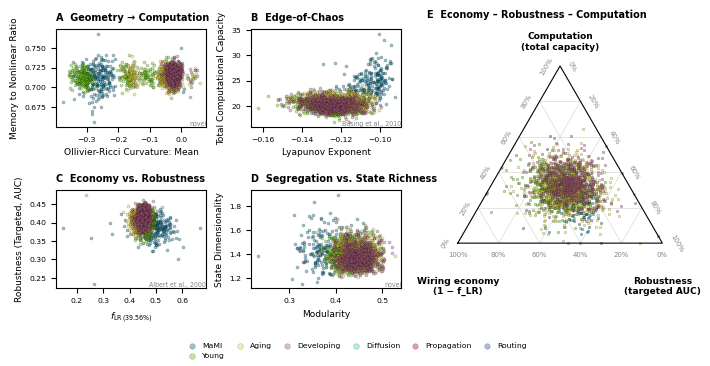

In [85]:
"""
Novel trade-off figure: 4 scatter plots + 1 ternary triangle.

Layout (mosaic):
    A B E E
    C D E E 

A: Memory–nonlinear ratio vs. mean Ricci curvature
B: Total capacity vs. Lyapunov exponent
C: Targeted robustness vs. proportion LR connections
D: State dimensionality vs. modularity
E: Ternary triangle (wiring economy – robustness – computation)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PathCollection
from pathlib import Path

INCLUDE_LEXIS = True

# ── Panel definitions (4 scatter plots) ───────────────────────────────────────
scatter_panels = {
    "A": {
        "x": "ollivier_ricci_curvature_orc_mean",
        "y": "computational_capacity_memory_nonlinear_ratio",
        "title": "Geometry → Computation",
        "note": "novel",
    },
    "B": {
        "x": "computational_capacity_lyapunov_exponent",
        "y": "computational_capacity_total_capacity",
        "title": "Edge-of-Chaos",
        "note": "Büsing et al., 2010",
    },
    "C": {
        "x": "proportion_long_range_connections_0.3956",
        "y": "targeted_attack_robustness_rob_targeted_auc",
        "title": "Economy vs. Robustness",
        "note": "Albert et al., 2000",
    },
    "D": {
        "x": "modularity",
        "y": "computational_capacity_state_dimensionality",
        "title": "Segregation vs. State Richness",
        "note": "novel",
    },
}

# ── Ternary axes (panel E) ────────────────────────────────────────────────────
ternary_cols = {
    "economy":     "proportion_long_range_connections_0.3956",
    "robustness":  "targeted_attack_robustness_rob_targeted_auc",
    "computation": "computational_capacity_total_capacity",
}
ternary_labels = {
    "economy":     "Wiring economy\n(1 − f_LR)",
    "robustness":  "Robustness\n(targeted AUC)",
    "computation": "Computation\n(total capacity)",
}


# ═════════════════════════════════════════════════════════════════════════════
#  Ternary helpers (no mpltern needed)
# ═════════════════════════════════════════════════════════════════════════════

# Vertices of equilateral triangle (bottom-left, bottom-right, top)
_TRI = np.array([
    [0.0,  0.0],                        # vertex 0: economy     (bottom-left)
    [1.0,  0.0],                        # vertex 1: robustness  (bottom-right)
    [0.5,  np.sqrt(3) / 2],             # vertex 2: computation (top)
])

def _bary_to_cart(a, b, c):
    """Convert barycentric (a, b, c) — already normalized to sum=1 — to 2-D Cartesian."""
    pts = np.column_stack([a, b, c])    # (N, 3)
    xy  = pts @ _TRI                    # (N, 2)
    return xy[:, 0], xy[:, 1]


def _draw_ternary_frame(ax):
    """Draw the triangle boundary, gridlines, and vertex labels."""
    # Triangle boundary
    tri_closed = np.vstack([_TRI, _TRI[0]])
    ax.plot(tri_closed[:, 0], tri_closed[:, 1], color="black", linewidth=0.8, zorder=5)

    # Gridlines at 20 % intervals
    for f in [0.2, 0.4, 0.6, 0.8]:
        for i, j, k in [(0,1,2), (1,2,0), (2,0,1)]:
            p0 = (1 - f) * _TRI[i] + f * _TRI[j]
            p1 = (1 - f) * _TRI[i] + f * _TRI[k]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color="#d0d0d0", linewidth=0.4, zorder=1)

    # Tick labels along each edge (20 % steps)
    fontsize = 5
    offset = 0.04
    for f in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        label = f"{f:.0%}" if f in (0, 1) else f"{f:.0%}"
        # Bottom edge (economy → robustness): economy fraction = 1-f
        px = (1 - f) * _TRI[0] + f * _TRI[1]
        ax.text(px[0], px[1] - offset, f"{1-f:.0%}",
                ha="center", va="top", fontsize=fontsize, color="#888888")
        # Left edge (economy → computation): computation fraction = f
        pl = (1 - f) * _TRI[0] + f * _TRI[2]
        ax.text(pl[0] - offset * 0.8, pl[1], f"{f:.0%}",
                ha="right", va="center", fontsize=fontsize, color="#888888", rotation=60)
        # Right edge (robustness → computation): robustness fraction = 1-f
        pr = (1 - f) * _TRI[1] + f * _TRI[2]
        ax.text(pr[0] + offset * 0.8, pr[1], f"{1-f:.0%}",
                ha="left", va="center", fontsize=fontsize, color="#888888", rotation=-60)

    # Vertex labels
    label_offset = 0.09
    ax.text(_TRI[0][0], _TRI[0][1] - label_offset * 1.8,
            ternary_labels["economy"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[1][0], _TRI[1][1] - label_offset * 1.8,
            ternary_labels["robustness"],
            ha="center", va="top", fontsize=6.5, fontweight="bold")
    ax.text(_TRI[2][0], _TRI[2][1] + label_offset * 0.8,
            ternary_labels["computation"],
            ha="center", va="bottom", fontsize=6.5, fontweight="bold")

    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.22, _TRI[2][1] + 0.18)
    ax.set_aspect("equal")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  Build figure
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplot_mosaic(
    """
    ABEE
    CDEE
    """,
    figsize=viz.cm_to_inch((18, 9)),
    layout="constrained",
)

# ── 1. Scatter panels A–D ────────────────────────────────────────────────────

for panel_id, cfg in scatter_panels.items():
    ax = axes[panel_id]

    for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
        
        if "gnm" in dataset:
            continue 
        
        df_merged = dict_with_all_datasets[dataset]
        
        if (not INCLUDE_LEXIS) and ("lexi" in dataset):
            print(f"Skipping {dataset} because it's a Lexis dataset and INCLUDE_LEXIS is False.")
            continue
        
        x_col, y_col = cfg["x"], cfg["y"]
        if x_col not in df_merged.columns or y_col not in df_merged.columns:
            continue

        is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

        ax.scatter(
            df_merged[x_col],
            df_merged[y_col],
            color=combined_colors if is_gnm else COLOR_SCHEME[dataset], # "gray" 
            edgecolor="black" if not is_gnm else "none",
            linewidth=0.25 if not is_gnm else 0,
            s=5,
            alpha=0.15 if is_gnm else 0.4,
            label=LABEL_MAP[dataset] if panel_id == "A" else None,
            zorder=1 if is_gnm else 2,
            rasterized=is_gnm,
        )

    ax.set_xlabel(PROPERTY_NAMES.get(cfg["x"], cfg["x"]), fontsize=6.5)
    ax.set_ylabel(PROPERTY_NAMES.get(cfg["y"], cfg["y"]), fontsize=6.5)
    ax.tick_params(labelsize=5.5)

    ax.set_title(f"{panel_id}  {cfg['title']}", fontsize=7, fontweight="bold", loc="left")
    ax.annotate(cfg["note"], xy=(1, 0), xycoords="axes fraction",
                fontsize=4.5, color="gray", ha="right", va="bottom")


# ── 2. Ternary panel E ───────────────────────────────────────────────────────

ax_t = axes["E"]
_draw_ternary_frame(ax_t)
ax_t.set_title("E  Economy – Robustness – Computation", fontsize=7,
               fontweight="bold", loc="left", pad=8)

for dataset in datasets_to_look_at: # , df_merged in dict_with_all_datasets.items():
    
    if "gnm" in dataset:
            continue 
        
    df_merged = dict_with_all_datasets[dataset]
    cols = list(ternary_cols.values())
    if not all(c in df_merged.columns for c in cols):
        continue

    raw = df_merged[cols].dropna()
    if len(raw) == 0:
        continue

    # For economy: invert LR fraction so that LOW LR = HIGH economy
    v_economy     = 1.0 - raw[ternary_cols["economy"]].values
    v_robustness  = raw[ternary_cols["robustness"]].values
    v_computation = raw[ternary_cols["computation"]].values

    # Min-max normalize each axis across ALL datasets jointly
    # (on first pass, collect global ranges; here we normalize per-panel
    #  using the data present — you may want to precompute global ranges)
    stack = np.column_stack([v_economy, v_robustness, v_computation])

    # Shift to non-negative & normalize rows to sum=1
    for col_idx in range(3):
        col_min = stack[:, col_idx].min()
        col_max = stack[:, col_idx].max()
        rng = col_max - col_min
        if rng > 1e-12:
            stack[:, col_idx] = (stack[:, col_idx] - col_min) / rng
        else:
            stack[:, col_idx] = 1.0 / 3.0

    row_sums = stack.sum(axis=1, keepdims=True)
    row_sums[row_sums < 1e-12] = 1.0
    stack /= row_sums

    x_cart, y_cart = _bary_to_cart(stack[:, 0], stack[:, 1], stack[:, 2])

    is_gnm = dataset == "hcp_schaefer_100_dataset_gnm"

    ax_t.scatter(
        x_cart, y_cart,
        color="gray" if is_gnm else COLOR_SCHEME[dataset],
        edgecolor="black" if not is_gnm else "none",
        linewidth=0.2 if not is_gnm else 0,
        s=4,
        alpha=0.1 if is_gnm else 0.45,
        zorder=1 if is_gnm else 2,
        rasterized=is_gnm,
    )


# ── 3. Shared legend ─────────────────────────────────────────────────────────

handles, labels = axes["A"].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="outside lower center",
    ncol=min(len(labels), 6),
    fontsize=5.5,
    markerscale=1.8,
    frameon=False,
    handletextpad=0.3,
    columnspacing=1.0,
)

# ── 4. Save ──────────────────────────────────────────────────────────────────

plt.savefig(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_w_o_gnms.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"trade_off_grid_novel{'_w_o_lexi' if INCLUDE_LEXIS else ''}_w_o_gnms.pdf")
plt.show()